# 12a — External Dataset Quality Check

Validate `external_camera_validation/` before running notebook 12.

**Actual folder structure discovered:**
```
external_camera_validation/
├── Cataract/
│   ├── immature/    ← 107 images
│   └── mature/      ← 98 images
└── Normal/          ← 94 images (flat)
```

**Dataset characteristics:**
- Roboflow-augmented dataset: filenames follow `STEM.rf.HASH.jpg` pattern
- Original images: ~1100×700 px; augmented variants: 416×416 px
- All images are RGB
- Multiple augmented variants per source image (same stem, different hash)

**This notebook does NOT:** retrain models, delete files, or modify any existing asset.


In [26]:
# CELL 1 - Imports, paths, config, protected-file fingerprints
from __future__ import annotations
import hashlib, json, re, warnings
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, UnidentifiedImageError

warnings.filterwarnings("ignore")

PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent,
                            Path(r"D:/Practice Projects/Disease Detection")]
PROJECT_ROOT = next(
    (p for p in PROJECT_ROOT_CANDIDATES
     if (p / "dataset").exists() and (p / "preprocessing").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root.")

EXT_DIR      = PROJECT_ROOT / "external_camera_validation"
PREPARED_DIR = PROJECT_ROOT / "camera_dataset_prepared"
REPORT_DIR   = PROJECT_ROOT / "reports" / "camera_classifier_external_validation"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

IMG_EXTS    = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}
MIN_SIDE_PX = 32
TARGET_MIN  = 30
# Top-level class folders — subdirectories within are allowed and flattened
CLASS_NAMES = ["Cataract", "Normal"]

# ── Protected-file fingerprints ────────────────────────────────────────────
PROTECTED_RELATIVE = [
    "model/camera_binary_classifier_best.keras",
    "model/efficientnetv2_b0_4class_best.keras",
    "model/efficientnetv2_b0_4class_final.keras",
    "preprocessing/dataset_metadata_v2.csv",
    "preprocessing/splits_v2/train.csv",
    "preprocessing/splits_v2/validation.csv",
    "preprocessing/splits_v2/test.csv",
    "backend/app/main.py",
    "backend/app/model_service.py",
    "backend/app/gradcam.py",
    "frontend/package.json",
]

def _fingerprint(path: Path) -> dict:
    if not path.exists():
        return {"exists": False, "size": None, "md5": None, "mtime_ns": None}
    data = path.read_bytes()
    return {"exists": True, "size": len(data),
            "md5": hashlib.md5(data).hexdigest(),
            "mtime_ns": path.stat().st_mtime_ns}

PROTECTED_BEFORE = {r: _fingerprint(PROJECT_ROOT / r) for r in PROTECTED_RELATIVE}

print("PROJECT_ROOT :", PROJECT_ROOT)
print("EXT_DIR      :", EXT_DIR, "| exists:", EXT_DIR.exists())
print("Protected files fingerprinted:", len(PROTECTED_BEFORE))


PROJECT_ROOT : d:\Practice Projects\Disease Detection
EXT_DIR      : d:\Practice Projects\Disease Detection\external_camera_validation | exists: True
Protected files fingerprinted: 11


In [27]:
# CELL 2 - Discover all images recursively under each class folder
# Handles nested subdirectories (e.g. Cataract/immature/, Cataract/mature/)
# Class label is determined by the TOP-LEVEL folder name only.

records = []
n_unsupported = 0
subdir_map = defaultdict(lambda: defaultdict(int))  # class -> subdir -> count

for class_name in CLASS_NAMES:
    class_dir = EXT_DIR / class_name
    if not class_dir.exists():
        print(f"WARNING: {class_dir} does not exist.")
        continue
    for fp in sorted(class_dir.rglob("*")):
        if not fp.is_file():
            continue
        if fp.suffix.lower() not in IMG_EXTS:
            n_unsupported += 1
            continue
        # Subdir label (relative to class_dir, or "(flat)" if directly inside)
        rel = fp.relative_to(class_dir)
        subdir = str(rel.parent) if rel.parent != Path(".") else "(flat)"
        subdir_map[class_name][subdir] += 1
        records.append({
            "path":      fp,
            "class":     class_name,
            "subdir":    subdir,
            "filename":  fp.name,
            "ext":       fp.suffix.lower(),
            "size_bytes": fp.stat().st_size,
        })

n_cataract = sum(1 for r in records if r["class"] == "Cataract")
n_normal   = sum(1 for r in records if r["class"] == "Normal")
total      = len(records)

print(f"Folder structure:")
for cls in CLASS_NAMES:
    cls_total = sum(subdir_map[cls].values())
    print(f"  {cls}/  ({cls_total} images)")
    for sub, cnt in sorted(subdir_map[cls].items()):
        print(f"    {sub}: {cnt}")

print(f"\nTotal images found : {total}")
print(f"  Cataract         : {n_cataract}")
print(f"  Normal           : {n_normal}")
print(f"  Unsupported ext  : {n_unsupported}")

HAS_IMAGES = total > 0
if not HAS_IMAGES:
    print("\nExternal images are not available yet.")


Folder structure:
  Cataract/  (205 images)
    immature: 107
    mature: 98
  Normal/  (94 images)
    (flat): 94

Total images found : 299
  Cataract         : 205
  Normal           : 94
  Unsupported ext  : 0


In [28]:
# CELL 3 - Readability, dimensions, colour mode
if not HAS_IMAGES:
    print("No images to check.")
else:
    n_unreadable = 0
    n_too_small  = 0
    n_grayscale  = 0
    n_rgba       = 0
    n_rgb        = 0
    size_counter = defaultdict(int)

    for r in records:
        try:
            with Image.open(r["path"]) as img:
                r["width"]    = img.width
                r["height"]   = img.height
                r["mode"]     = img.mode
                r["readable"] = True
            size_counter[(r["width"], r["height"])] += 1
            if r["width"] < MIN_SIDE_PX or r["height"] < MIN_SIDE_PX:
                n_too_small += 1
                print(f"  TOO SMALL ({r['width']}x{r['height']}): {r['class']}/{r['filename']}")
            if r["mode"] in ("L", "LA", "P"):
                n_grayscale += 1
                print(f"  GRAYSCALE mode={r['mode']}: {r['class']}/{r['filename']}")
            elif r["mode"] == "RGBA":
                n_rgba += 1
            else:
                n_rgb += 1
        except (UnidentifiedImageError, Exception) as e:
            r["width"] = r["height"] = r["mode"] = None
            r["readable"] = False
            n_unreadable += 1
            print(f"  UNREADABLE: {r['class']}/{r['filename']} -> {e}")

    readable = [r for r in records if r.get("readable")]
    widths  = [r["width"]  for r in readable]
    heights = [r["height"] for r in readable]

    print(f"Image property summary ({len(readable)} readable):")
    print(f"  Unreadable  : {n_unreadable}")
    print(f"  Too small   : {n_too_small}  (< {MIN_SIDE_PX}px)")
    print(f"  RGB         : {n_rgb}")
    print(f"  RGBA        : {n_rgba}  (auto-converted to RGB at inference)")
    print(f"  Grayscale   : {n_grayscale}  (WARNING: model expects RGB)")
    print(f"\nDimension stats:")
    print(f"  Width  -> min:{min(widths)}  max:{max(widths)}  mean:{int(sum(widths)/len(widths))}")
    print(f"  Height -> min:{min(heights)} max:{max(heights)} mean:{int(sum(heights)/len(heights))}")
    print(f"\nTop dimension groups:")
    for size, cnt in sorted(size_counter.items(), key=lambda x: -x[1])[:5]:
        print(f"  {size[0]}x{size[1]}: {cnt} images")


Image property summary (299 readable):
  Unreadable  : 0
  Too small   : 0  (< 32px)
  RGB         : 299
  RGBA        : 0  (auto-converted to RGB at inference)
  Grayscale   : 0  (WARNING: model expects RGB)

Dimension stats:
  Width  -> min:416  max:1110  mean:619
  Height -> min:416 max:700 mean:501

Top dimension groups:
  416x416: 207 images
  1100x700: 87 images
  1110x700: 1 images
  576x576: 1 images
  596x596: 1 images


In [29]:
# CELL 4 - Roboflow augmentation variant analysis
# Filenames follow: STEM.rf.HASH.ext or STEM_jpg.rf.HASH.ext
# Multiple files sharing the same STEM are augmented variants of the same source image.
# This is expected for Roboflow datasets and is NOT treated as a quality failure.
if not HAS_IMAGES:
    print("No images to check.")
else:
    def extract_source_stem(filename: str) -> str:
        stem = Path(filename).stem
        m = re.match(r'^(.+?)(?:_jpg|_JPG|_jpeg|_png|_bmp)?\.rf\.[A-Za-z0-9]+$', stem)
        return m.group(1) if m else stem

    stem_groups = defaultdict(list)   # source_stem -> list of records
    for r in records:
        source = extract_source_stem(r["filename"])
        r["source_stem"] = source
        stem_groups[source].append(r)

    is_roboflow = sum(1 for r in records if ".rf." in r["filename"])
    multi_variant = {k: v for k, v in stem_groups.items() if len(v) > 1}
    single_source = {k: v for k, v in stem_groups.items() if len(v) == 1}

    print(f"Roboflow augmentation analysis:")
    print(f"  Total images              : {total}")
    print(f"  Roboflow-pattern filenames: {is_roboflow}")
    print(f"  Unique source stems       : {len(stem_groups)}")
    print(f"  Sources with >1 variant   : {len(multi_variant)}")
    print(f"  Sources with 1 image only : {len(single_source)}")
    print(f"  Total augmented copies    : {sum(len(v)-1 for v in multi_variant.values())}")
    print()
    print("NOTE: Multiple variants per source stem are EXPECTED in Roboflow datasets.")
    print("      They are augmented copies of the same original image.")
    print("      This is NOT treated as a duplication error.")
    print()

    # Show variant count distribution
    variant_counts = sorted([len(v) for v in stem_groups.values()], reverse=True)
    from collections import Counter
    vc = Counter(variant_counts)
    print("Variants per source stem:")
    for n_var, n_stems in sorted(vc.items()):
        print(f"  {n_var} variant(s): {n_stems} source stems")


Roboflow augmentation analysis:
  Total images              : 299
  Roboflow-pattern filenames: 299
  Unique source stems       : 57
  Sources with >1 variant   : 56
  Sources with 1 image only : 1
  Total augmented copies    : 242

NOTE: Multiple variants per source stem are EXPECTED in Roboflow datasets.
      They are augmented copies of the same original image.
      This is NOT treated as a duplication error.

Variants per source stem:
  1 variant(s): 1 source stems
  2 variant(s): 7 source stems
  3 variant(s): 14 source stems
  4 variant(s): 2 source stems
  5 variant(s): 5 source stems
  6 variant(s): 9 source stems
  7 variant(s): 8 source stems
  8 variant(s): 5 source stems
  9 variant(s): 2 source stems
  10 variant(s): 3 source stems
  11 variant(s): 1 source stems


In [30]:
# CELL 5 - Exact duplicate detection (MD5 hash)
# Detects byte-identical files. Roboflow augmented variants are NOT byte-identical.
if not HAS_IMAGES:
    print("No images to check.")
else:
    print("Computing MD5 hashes...")
    hash_map = defaultdict(list)
    for r in records:
        if not r.get("readable", False):
            r["md5"] = None
            continue
        r["md5"] = hashlib.md5(r["path"].read_bytes()).hexdigest()
        hash_map[r["md5"]].append(r)

    exact_dup_groups = {h: recs for h, recs in hash_map.items() if len(recs) > 1}
    n_exact_dups = sum(len(v) - 1 for v in exact_dup_groups.values())

    print(f"Exact duplicate groups (byte-identical): {len(exact_dup_groups)}")
    if exact_dup_groups:
        for h, recs in exact_dup_groups.items():
            print(f"  Hash {h[:12]}: {[r['filename'] for r in recs]}")
    else:
        print("  No byte-identical duplicates found.")
    print(f"Total redundant exact copies: {n_exact_dups}")


Computing MD5 hashes...
Exact duplicate groups (byte-identical): 0
  No byte-identical duplicates found.
Total redundant exact copies: 0


In [31]:
# CELL 6 - Overlap check against camera_dataset_prepared/
# Uses MD5 hash comparison. Filename match alone is NOT treated as duplication.
# Roboflow augmented variants may share stems with training data but differ in content.
if not HAS_IMAGES:
    print("No images to check.")
else:
    print("Building MD5 index for camera_dataset_prepared/ ...")
    prepared_hashes   = set()
    prepared_filenames = set()
    n_prepared = 0

    if PREPARED_DIR.exists():
        for fp in PREPARED_DIR.rglob("*"):
            if fp.is_file() and fp.suffix.lower() in IMG_EXTS:
                try:
                    prepared_hashes.add(hashlib.md5(fp.read_bytes()).hexdigest())
                    prepared_filenames.add(fp.name.lower())
                    n_prepared += 1
                except Exception:
                    pass
        print(f"  Indexed {n_prepared} images from camera_dataset_prepared/")
    else:
        print("  camera_dataset_prepared/ not found.")

    hash_overlaps      = [r for r in records if r.get("md5") and r["md5"] in prepared_hashes]
    filename_warnings  = [r for r in records
                          if r["filename"].lower() in prepared_filenames
                          and r not in hash_overlaps]

    print(f"\nOverlap results:")
    print(f"  Hash-confirmed overlaps (same file content) : {len(hash_overlaps)}")
    print(f"  Filename-only warnings (different content)  : {len(filename_warnings)}")
    if hash_overlaps:
        for r in hash_overlaps:
            print(f"    OVERLAP: {r['class']}/{r['filename']}")
    else:
        print("  No content-identical images found in training/val/test sets.")
    if filename_warnings:
        print("  Filename warnings (same name, different hash — likely different augmentation):")
        for r in filename_warnings[:5]:
            print(f"    {r['class']}/{r['filename']}")


Building MD5 index for camera_dataset_prepared/ ...
  Indexed 1870 images from camera_dataset_prepared/

Overlap results:
  Hash-confirmed overlaps (same file content) : 0
  Filename-only warnings (different content)  : 0
  No content-identical images found in training/val/test sets.


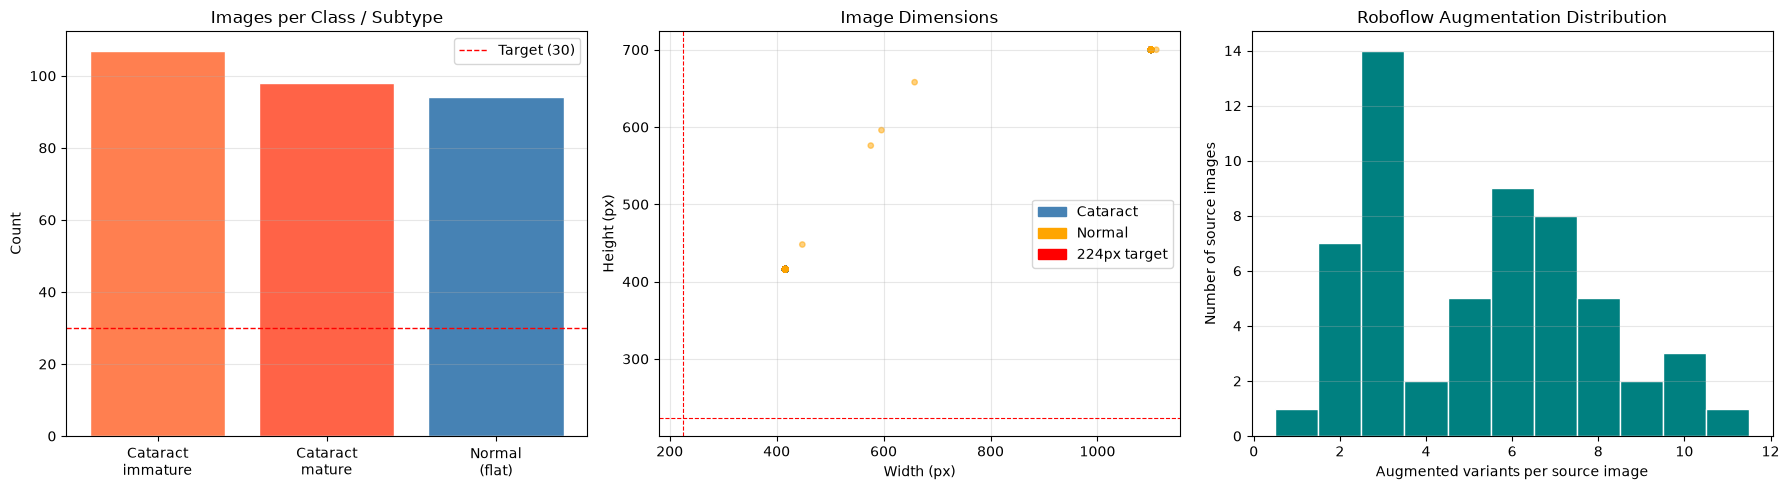

Saved: external_dataset_quality.png


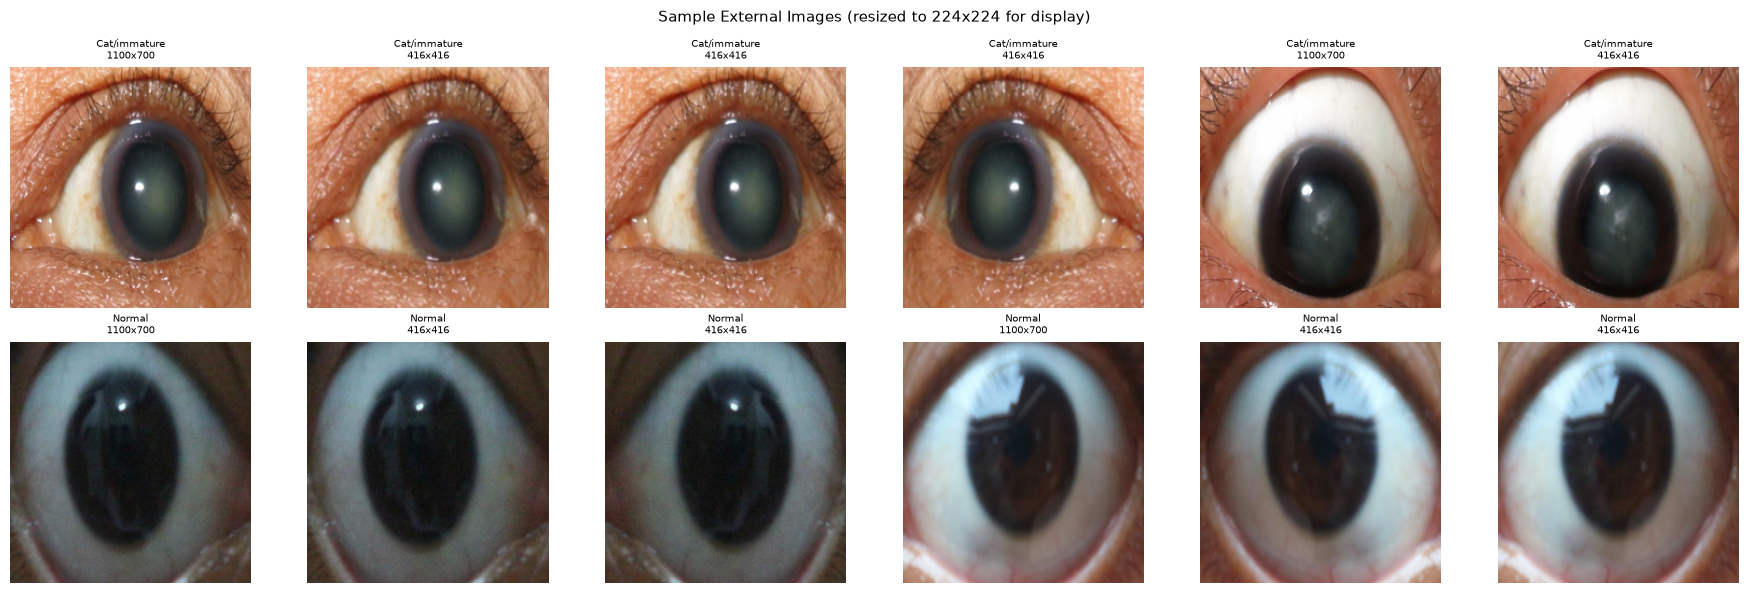

Saved: external_dataset_samples.png


In [32]:
# CELL 7 - Visualisations
if not HAS_IMAGES:
    print("No images to visualise.")
else:
    readable = [r for r in records if r.get("readable")]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Class + subdir breakdown bar chart
    subdir_data = defaultdict(lambda: defaultdict(int))
    for r in readable:
        subdir_data[r["class"]][r["subdir"]] += 1

    bar_labels, bar_vals, bar_colors = [], [], []
    color_map = {"(flat)": "steelblue", "immature": "coral", "mature": "tomato"}
    for cls in CLASS_NAMES:
        for sub, cnt in sorted(subdir_data[cls].items()):
            bar_labels.append(f"{cls}\n{sub}")
            bar_vals.append(cnt)
            bar_colors.append(color_map.get(sub, "teal"))
    axes[0].bar(bar_labels, bar_vals, color=bar_colors, edgecolor="white")
    axes[0].set_title("Images per Class / Subtype")
    axes[0].set_ylabel("Count")
    axes[0].axhline(TARGET_MIN, color="red", linestyle="--", linewidth=1, label=f"Target ({TARGET_MIN})")
    axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

    # 2. Dimension scatter
    colors_scatter = ["steelblue" if r["class"] == "Cataract" else "orange" for r in readable]
    axes[1].scatter([r["width"] for r in readable], [r["height"] for r in readable],
                    c=colors_scatter, alpha=0.5, s=15)
    axes[1].set_xlabel("Width (px)"); axes[1].set_ylabel("Height (px)")
    axes[1].set_title("Image Dimensions")
    axes[1].axvline(224, color="red", linestyle="--", linewidth=0.8)
    axes[1].axhline(224, color="red", linestyle="--", linewidth=0.8)
    axes[1].legend(handles=[
        mpatches.Patch(color="steelblue", label="Cataract"),
        mpatches.Patch(color="orange",    label="Normal"),
        mpatches.Patch(color="red",       label="224px target"),
    ]); axes[1].grid(True, alpha=0.3)

    # 3. Augmented variants per source stem
    variant_counts = [len(v) for v in stem_groups.values()]
    axes[2].hist(variant_counts, bins=range(1, max(variant_counts)+2), color="teal",
                 edgecolor="white", align="left")
    axes[2].set_xlabel("Augmented variants per source image")
    axes[2].set_ylabel("Number of source images")
    axes[2].set_title("Roboflow Augmentation Distribution")
    axes[2].grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig(str(REPORT_DIR / "external_dataset_quality.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: external_dataset_quality.png")

    # Sample grid
    fig2, axes2 = plt.subplots(2, 6, figsize=(18, 6))
    sample_cat  = [r for r in readable if r["class"] == "Cataract"][:6]
    sample_norm = [r for r in readable if r["class"] == "Normal"][:6]
    for col, r in enumerate(sample_cat):
        axes2[0][col].imshow(Image.open(r["path"]).resize((224,224)))
        axes2[0][col].set_title(f"Cat/{r['subdir']}\n{r['width']}x{r['height']}", fontsize=7)
        axes2[0][col].axis("off")
    for col, r in enumerate(sample_norm):
        axes2[1][col].imshow(Image.open(r["path"]).resize((224,224)))
        axes2[1][col].set_title(f"Normal\n{r['width']}x{r['height']}", fontsize=7)
        axes2[1][col].axis("off")
    for col in range(len(sample_cat), 6): axes2[0][col].axis("off")
    for col in range(len(sample_norm), 6): axes2[1][col].axis("off")
    axes2[0][0].set_ylabel("Cataract", fontsize=9)
    axes2[1][0].set_ylabel("Normal",   fontsize=9)
    fig2.suptitle("Sample External Images (resized to 224x224 for display)", fontsize=11)
    plt.tight_layout()
    plt.savefig(str(REPORT_DIR / "external_dataset_samples.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: external_dataset_samples.png")


In [33]:
# CELL 8 - Save per-image quality report CSV
if not HAS_IMAGES:
    print("No images — CSV not saved.")
else:
    df_q = pd.DataFrame([{
        "class":        r["class"],
        "subdir":       r["subdir"],
        "filename":     r["filename"],
        "source_stem":  r.get("source_stem", ""),
        "ext":          r["ext"],
        "size_bytes":   r["size_bytes"],
        "width":        r.get("width"),
        "height":       r.get("height"),
        "mode":         r.get("mode"),
        "readable":     r.get("readable", False),
        "md5":          r.get("md5"),
        "too_small":    (r.get("width", 999) < MIN_SIDE_PX or
                         r.get("height", 999) < MIN_SIDE_PX) if r.get("readable") else None,
        "exact_dup":    r.get("md5") in {h for h,v in hash_map.items() if len(v)>1}
                        if r.get("md5") else False,
        "in_prepared":  r.get("md5") in prepared_hashes if r.get("md5") else False,
    } for r in records])

    csv_path = REPORT_DIR / "external_dataset_quality_report.csv"
    df_q.to_csv(str(csv_path), index=False)
    print(f"Quality report saved: {csv_path}")
    print(f"\nSummary by class:")
    print(df_q.groupby(["class","subdir"]).size().to_string())


Quality report saved: d:\Practice Projects\Disease Detection\reports\camera_classifier_external_validation\external_dataset_quality_report.csv

Summary by class:
class     subdir  
Cataract  immature    107
          mature       98
Normal    (flat)       94


In [34]:
# CELL 9 - Isolation validation + final status
print("=" * 60)
print("ISOLATION VALIDATION")
print("=" * 60)
all_ok = True
for rel, before in PROTECTED_BEFORE.items():
    after = _fingerprint(PROJECT_ROOT / rel)
    if not before["exists"]:
        status = "SKIP (did not exist before)"
    elif before["md5"] != after["md5"] or before["mtime_ns"] != after["mtime_ns"]:
        status = "MODIFIED  <-- WARNING"; all_ok = False
    else:
        status = "UNCHANGED OK"
    print(f"  {rel:<55} {status}")

print()
print("=" * 60)

if not HAS_IMAGES:
    print("EXTERNAL DATASET STATUS: SKIPPED")
    print("=" * 60)
    print("\nExternal images are not available yet. Add genuinely unseen Normal and")
    print("Cataract camera images to external_camera_validation/ and re-run.")
else:
    has_warnings = (
        n_unreadable > 0 or
        n_exact_dups > 0 or
        len(hash_overlaps) > 0 or
        n_normal < TARGET_MIN or
        n_cataract < TARGET_MIN
    )
    overall = "WARNING" if has_warnings else "PASS"

    print(f"EXTERNAL DATASET STATUS: {overall}")
    print("=" * 60)
    print(f"\nNormal images  : {n_normal}")
    print(f"Cataract images: {n_cataract}  (immature: {subdir_map['Cataract'].get('immature',0)}  mature: {subdir_map['Cataract'].get('mature',0)})")
    print(f"Total images   : {total}")
    print()
    print(f"Unreadable images     : {n_unreadable}")
    print(f"Exact duplicate images: {n_exact_dups}")
    print(f"Too-small images      : {n_too_small}")
    print()
    print(f"Normal >= 30   : {'PASS' if n_normal   >= TARGET_MIN else 'FAIL'}")
    print(f"Cataract >= 30 : {'PASS' if n_cataract >= TARGET_MIN else 'FAIL'}")
    print()
    print(f"Previously used image overlap: {len(hash_overlaps)} / {total}")
    print()
    print(f"Roboflow source stems : {len(stem_groups)}")
    print(f"Augmented variants    : {sum(len(v)-1 for v in stem_groups.values())} extra copies")
    print()
    print("Existing model modified        : NO")
    print("Existing fundus dataset modified: NO")
    print("Backend modified               : NO")
    print("Frontend modified              : NO")
    print()

    # Notebook 12 compatibility note
    print("=" * 60)
    print("NOTEBOOK 12 COMPATIBILITY NOTE")
    print("=" * 60)
    print("Notebook 12 expects images directly under Cataract/ and Normal/.")
    print("This dataset has Cataract/immature/ and Cataract/mature/ subdirectories.")
    print("Notebook 12 must be updated to use rglob() instead of iterdir()")
    print("so it correctly discovers all Cataract images recursively.")
    print()

    if overall == "PASS":
        print("CONCLUSION: Dataset passes quality checks.")
        print("Update notebook 12 path discovery before running external validation.")
    else:
        if n_normal < TARGET_MIN:
            print(f"WARNING: Only {n_normal} Normal images (target >= {TARGET_MIN}).")
        if n_unreadable:
            print(f"WARNING: {n_unreadable} unreadable images found.")
        if hash_overlaps:
            print(f"WARNING: {len(hash_overlaps)} images overlap with training data.")
        print("Resolve warnings above before running notebook 12.")


ISOLATION VALIDATION
  model/camera_binary_classifier_best.keras               UNCHANGED OK
  model/efficientnetv2_b0_4class_best.keras               UNCHANGED OK
  model/efficientnetv2_b0_4class_final.keras              UNCHANGED OK
  preprocessing/dataset_metadata_v2.csv                   UNCHANGED OK
  preprocessing/splits_v2/train.csv                       UNCHANGED OK
  preprocessing/splits_v2/validation.csv                  UNCHANGED OK
  preprocessing/splits_v2/test.csv                        UNCHANGED OK
  backend/app/main.py                                     UNCHANGED OK
  backend/app/model_service.py                            UNCHANGED OK
  backend/app/gradcam.py                                  UNCHANGED OK
  frontend/package.json                                   UNCHANGED OK

EXTERNAL DATASET STATUS: PASS

Normal images  : 94
Cataract images: 205  (immature: 107  mature: 98)
Total images   : 299

Unreadable images     : 0
Exact duplicate images: 0
Too-small images      